# Deteksi Anomali Ekonomi Makro — Local Outlier Factor (LOF)

**Early Warning System Krisis Ekonomi menggunakan Local Outlier Factor (Density-Based)**

---

Notebook ini mengimplementasikan pendekatan **Local Outlier Factor (LOF)** untuk mendeteksi anomali pada indikator ekonomi makro sebagai sistem peringatan dini (*Early Warning System*) krisis ekonomi.

**Metodologi:**
- Prinsip: Perbandingan kerapatan lokal (*local density comparison*) antar observasi
- Grid Search: 5 variasi `n_neighbors` x 4 variasi `contamination` = 20 kombinasi
- Evaluasi: Precision, Recall, F1-Score, ROC-AUC terhadap *ground truth* krisis historis
- Interpretasi: Analisis LOF Score per negara dan per krisis historis

**Dataset:** 14 indikator makroekonomi, 49 negara, periode 1990-2024 (World Bank Open Data)  
**Disusun oleh:** Amir

## 1. Instalasi & Import Library

In [51]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, average_precision_score,
    precision_recall_curve, roc_auc_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

SEED = 42
np.random.seed(SEED)

print('Library berhasil diimport')
import sklearn; print(f'scikit-learn: {sklearn.__version__}')

Library berhasil diimport
scikit-learn: 1.8.0


## 2. Load & Eksplorasi Data

In [52]:
df = pd.read_csv('data_cleaned.csv')

print(f'Shape dataset: {df.shape}')
print(f'Jumlah negara: {df["economy"].nunique()}')
print(f'Rentang tahun: {df["year"].min()} - {df["year"].max()}')
print(f'\nDistribusi crisis_label:')
print(df['crisis_label'].value_counts())
print(f'\nPersentase krisis: {df["crisis_label"].mean()*100:.2f}%')

df.head()

Shape dataset: (1714, 17)
Jumlah negara: 49
Rentang tahun: 1990 - 2024

Distribusi crisis_label:
crisis_label
0    1385
1     329
Name: count, dtype: int64

Persentase krisis: 19.19%


,economy,year,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP,crisis_label
0,ARE,1990,2.690913,2.607447,-0.035597,-0.349079,-1.105892,2.12939,0.234573,-0.486899,0.326385,0.123081,1.10385,-0.224663,-1.589531,-0.270213,0
1,ARE,1991,-0.638363,-1.838101,-0.035597,-0.347005,-1.105892,2.12939,0.234573,-0.448764,0.326385,0.123081,1.10385,-0.224663,-1.601884,-0.270213,0
2,ARE,1992,0.032110,-1.108947,-0.035597,-0.346099,-1.087378,2.12939,0.234573,-0.422930,0.326385,0.123081,1.10385,-0.224663,-1.573871,-0.270213,0
3,ARE,1993,-0.530135,-1.574741,-0.035597,-0.344897,-1.047336,2.12939,0.234573,-0.356948,0.326385,0.123081,1.10385,-0.224663,-1.528502,-0.270213,0
4,ARE,1994,0.990307,-0.018863,-0.035597,-0.343393,-1.061760,2.12939,0.234573,-0.441240,0.326385,0.123081,1.10385,-0.224663,-1.747591,-0.270213,0


In [53]:
FEATURE_COLS = [
    'GDP_Growth', 'GDP_PerCapita_Growth', 'Inflation_CPI',
    'Total_Reserves', 'Unemployment', 'Current_Account_GDP',
    'Trade_GDP', 'FDI_Inflows_GDP', 'Exports_GDP', 'Imports_GDP',
    'Gross_Savings_GDP', 'Exchange_Rate', 'Manufacturing_Value',
    'Investment_GDP'
]

FEATURE_LABELS = {
    'GDP_Growth': 'Pertumbuhan PDB (%)',
    'GDP_PerCapita_Growth': 'PDB per Kapita Growth (%)',
    'Inflation_CPI': 'Inflasi CPI (%)',
    'Total_Reserves': 'Cadangan Devisa',
    'Unemployment': 'Pengangguran (%)',
    'Current_Account_GDP': 'Neraca Berjalan/PDB (%)',
    'Trade_GDP': 'Perdagangan/PDB (%)',
    'FDI_Inflows_GDP': 'FDI Masuk/PDB (%)',
    'Exports_GDP': 'Ekspor/PDB (%)',
    'Imports_GDP': 'Impor/PDB (%)',
    'Gross_Savings_GDP': 'Tabungan Bruto/PDB (%)',
    'Exchange_Rate': 'Nilai Tukar (LCU/USD)',
    'Manufacturing_Value': 'Manufaktur/PDB (%)',
    'Investment_GDP': 'Investasi/PDB (%)'
}

print(f'Jumlah fitur: {len(FEATURE_COLS)}')
print(f'Missing values per fitur:')
print(df[FEATURE_COLS].isnull().sum())
print(f'\nStatistik deskriptif:')
df[FEATURE_COLS].describe().round(3)

Jumlah fitur: 14
Missing values per fitur:
GDP_Growth              0
GDP_PerCapita_Growth    0
Inflation_CPI           0
Total_Reserves          0
Unemployment            0
Current_Account_GDP     0
Trade_GDP               0
FDI_Inflows_GDP         0
Exports_GDP             0
Imports_GDP             0
Gross_Savings_GDP       0
Exchange_Rate           0
Manufacturing_Value     0
Investment_GDP          0
dtype: int64

Statistik deskriptif:


,GDP_Growth,GDP_PerCapita_Growth,Inflation_CPI,Total_Reserves,Unemployment,Current_Account_GDP,Trade_GDP,FDI_Inflows_GDP,Exports_GDP,Imports_GDP,Gross_Savings_GDP,Exchange_Rate,Manufacturing_Value,Investment_GDP
count,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000,1714.000
mean,-0.002,-0.001,-0.035,-0.003,-0.004,0.001,-0.003,-0.005,-0.003,-0.002,-0.000,-0.002,-0.001,-0.002
std,0.977,0.982,0.268,0.969,0.982,0.980,0.985,0.852,0.985,0.985,0.996,0.983,0.996,0.989
min,-3.815,-3.711,-0.100,-0.360,-1.329,-2.310,-1.058,-3.011,-1.016,-1.120,-2.163,-0.226,-1.915,-1.987
25%,-0.477,-0.429,-0.084,-0.322,-0.654,-0.615,-0.578,-0.342,-0.581,-0.591,-0.729,-0.226,-0.749,-0.635
50%,0.005,0.012,-0.077,-0.259,-0.261,-0.178,-0.303,-0.185,-0.310,-0.292,-0.157,-0.224,-0.090,-0.150
75%,0.561,0.580,-0.058,-0.095,0.360,0.368,0.186,0.046,0.200,0.212,0.612,-0.205,0.559,0.425
max,2.691,2.758,3.206,8.628,4.312,3.879,5.122,5.938,5.054,5.143,3.072,7.330,2.674,3.378


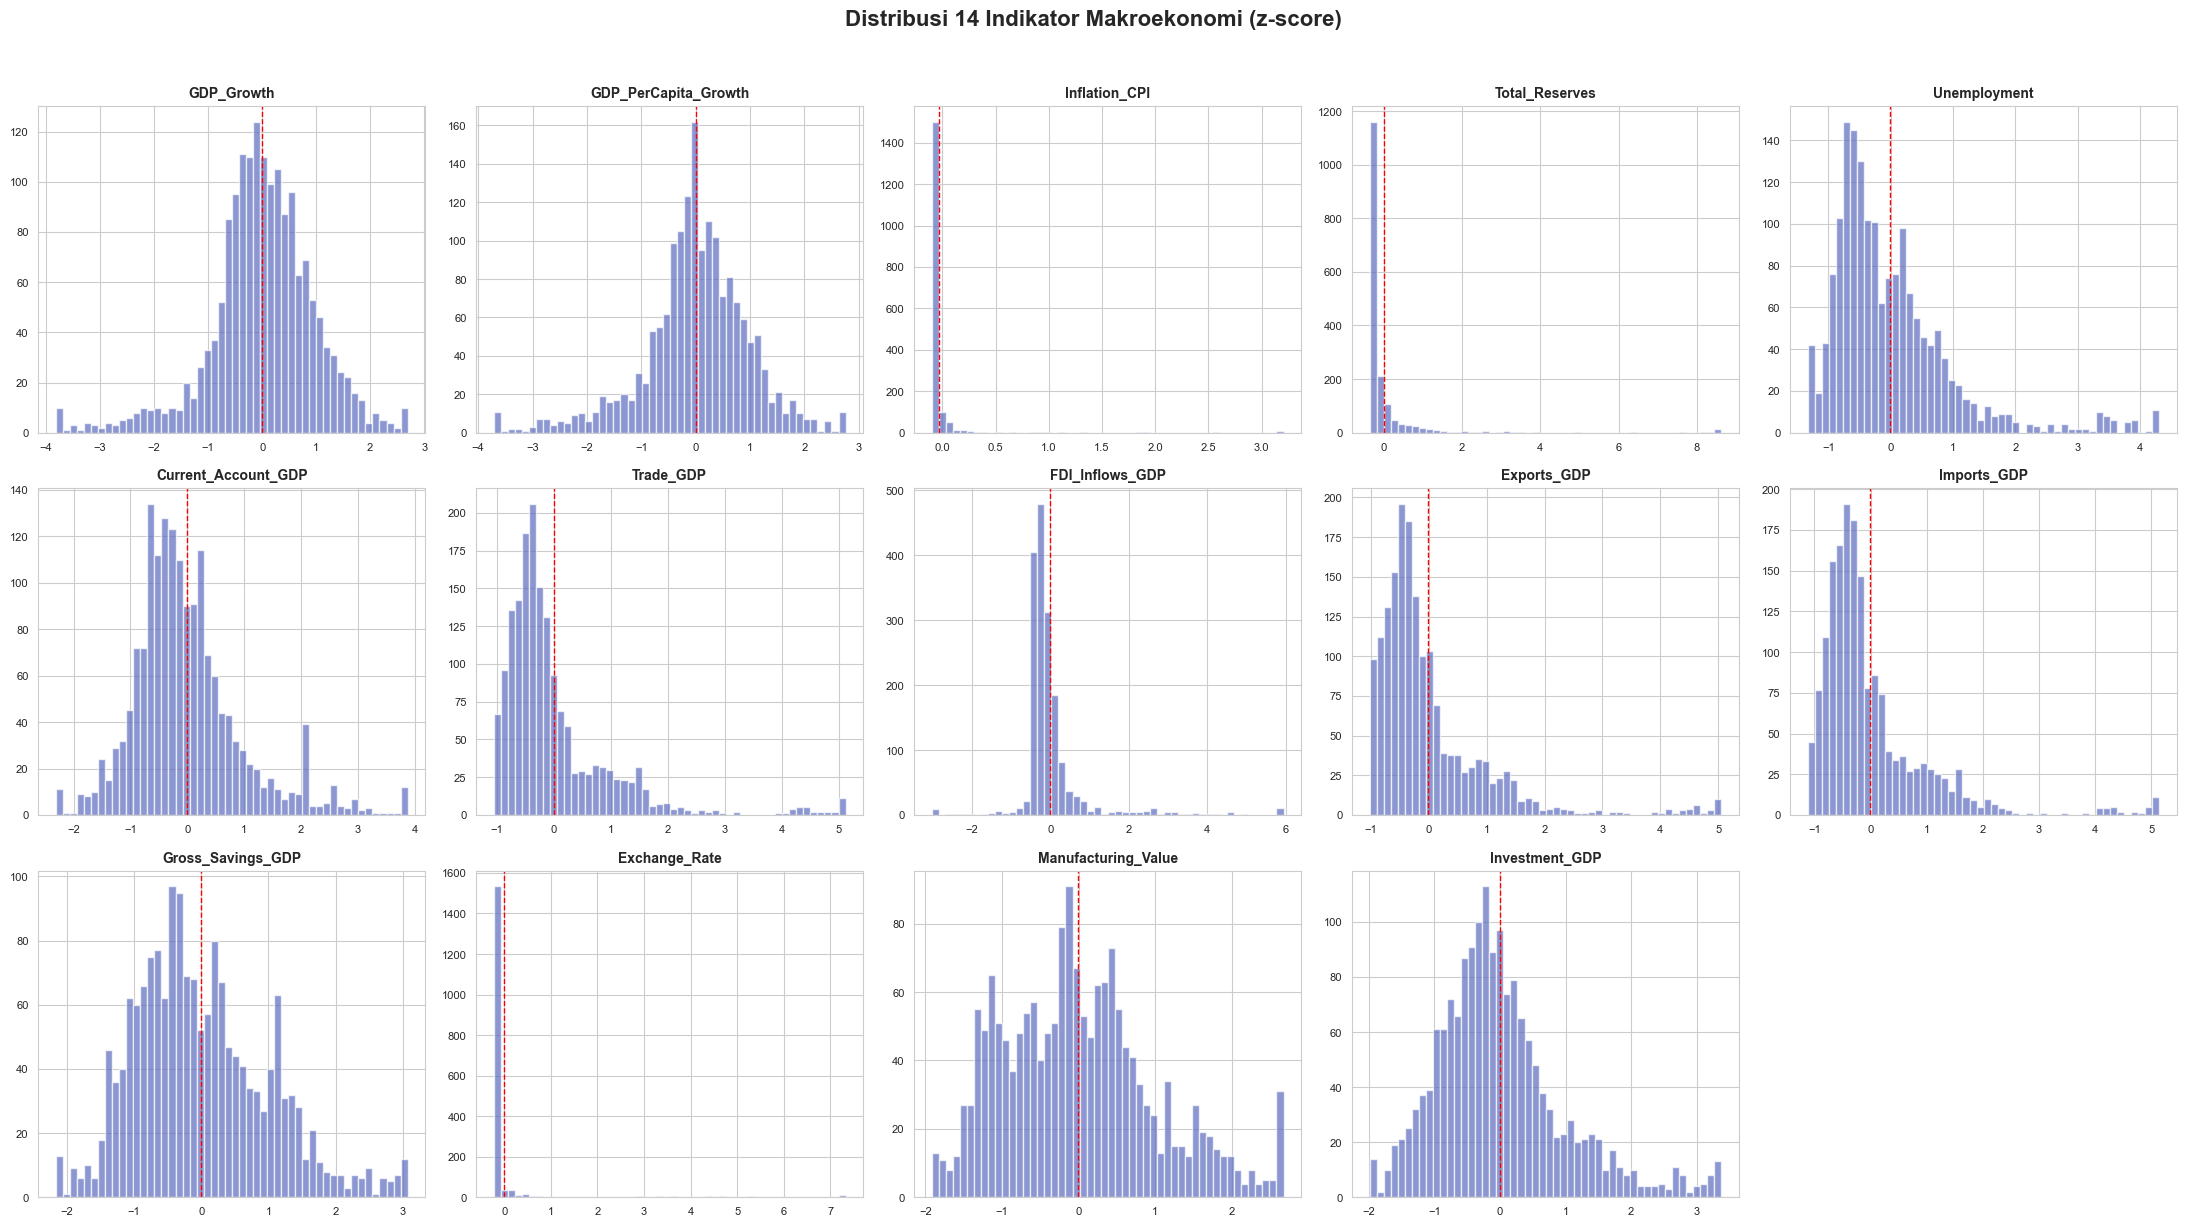

In [54]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    ax.hist(df[col], bins=50, alpha=0.7, color='#5C6BC0', edgecolor='white')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1)
    ax.tick_params(labelsize=8)

axes[-1].set_visible(False)
fig.suptitle('Distribusi 14 Indikator Makroekonomi (z-score)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Konsep Local Outlier Factor

### Prinsip Kerja LOF

LOF mengukur derajat anomali suatu titik data secara **relatif terhadap kerapatan lokal** tetangga-tetangganya:

1. **k-distance(p)**: Jarak dari titik p ke tetangga ke-k terdekatnya
2. **Reachability Distance**: `reach-dist_k(p,o) = max(k-dist(o), d(p,o))`
3. **Local Reachability Density (LRD)**: Kebalikan rata-rata reachability distance ke k-tetangga
4. **LOF Score**: Rasio rata-rata LRD tetangga / LRD titik itu sendiri

- **LOF ~ 1** => Titik berada di area dengan kerapatan serupa => **Normal**
- **LOF >> 1** => Titik berada di area jauh lebih jarang dari tetangganya => **Anomali**

## 4. Persiapan Data

In [55]:
X = df[FEATURE_COLS].values
y_true = df['crisis_label'].values

print(f'Shape fitur (X): {X.shape}')
print(f'Shape label (y): {y_true.shape}')
print(f'Jumlah krisis (label=1): {y_true.sum()} ({y_true.mean()*100:.1f}%)')
print(f'Jumlah normal (label=0): {(y_true==0).sum()} ({(1-y_true.mean())*100:.1f}%)')
print('\nCatatan: LOF dilatih secara UNSUPERVISED -- crisis_label hanya digunakan untuk evaluasi post-hoc')

Shape fitur (X): (1714, 14)
Shape label (y): (1714,)
Jumlah krisis (label=1): 329 (19.2%)
Jumlah normal (label=0): 1385 (80.8%)

Catatan: LOF dilatih secara UNSUPERVISED -- crisis_label hanya digunakan untuk evaluasi post-hoc


## 5. Grid Search Hyperparameter

### Parameter yang Diuji:
- **`n_neighbors`**: [5, 10, 20, 30, 50] -- mendefinisikan ukuran lingkungan lokal
- **`contamination`**: ['auto', 0.10, 0.15, 0.1919] -- proporsi estimasi anomali

In [56]:
N_NEIGHBORS_LIST   = [5, 10, 20, 30, 50]
CONTAMINATION_LIST = ['auto', 0.10, 0.15, 0.1919]

results = []

print('Menjalankan Grid Search LOF...')
print('='*80)
print(f'{"n_neighbors":>12} {"contamination":>15} {"TP":>5} {"FP":>5} {"TN":>6} {"FN":>5} '
      f'{"Prec":>7} {"Rec":>7} {"F1":>7} {"AUC":>7}')
print('-'*80)

for n_neighbors in N_NEIGHBORS_LIST:
    for contamination in CONTAMINATION_LIST:
        lof = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=contamination,
            metric='minkowski',
            algorithm='auto',
            novelty=False
        )
        pred = lof.fit_predict(X)
        pred_binary = (pred == -1).astype(int)
        scores = -lof.negative_outlier_factor_

        tn, fp, fn, tp = confusion_matrix(y_true, pred_binary).ravel()
        prec = precision_score(y_true, pred_binary, zero_division=0)
        rec  = recall_score(y_true, pred_binary, zero_division=0)
        f1   = f1_score(y_true, pred_binary, zero_division=0)
        roc  = roc_auc_score(y_true, scores)
        ap   = average_precision_score(y_true, scores)

        results.append({
            'n_neighbors': n_neighbors,
            'contamination': contamination,
            'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
            'Precision': round(prec, 4),
            'Recall':    round(rec, 4),
            'F1-Score':  round(f1, 4),
            'ROC-AUC':   round(roc, 4),
            'Avg Precision': round(ap, 4)
        })

        cont_str = str(contamination)
        print(f'{n_neighbors:>12} {cont_str:>15} {tp:>5} {fp:>5} {tn:>6} {fn:>5} '
              f'{prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {roc:>7.4f}')

print('='*80)
print('Grid Search selesai!')
df_results = pd.DataFrame(results)

Menjalankan Grid Search LOF...
 n_neighbors   contamination    TP    FP     TN    FN    Prec     Rec      F1     AUC
--------------------------------------------------------------------------------
           5            auto    30    50   1335   299  0.3750  0.0912  0.1467  0.6547
           5             0.1    62   110   1275   267  0.3605  0.1884  0.2475  0.6547
           5            0.15    88   169   1216   241  0.3424  0.2675  0.3003  0.6547
           5          0.1919   107   222   1163   222  0.3252  0.3252  0.3252  0.6547
          10            auto    28    26   1359   301  0.5185  0.0851  0.1462  0.6794
          10             0.1    70   102   1283   259  0.4070  0.2128  0.2794  0.6794
          10            0.15    94   163   1222   235  0.3658  0.2857  0.3208  0.6794
          10          0.1919   113   216   1169   216  0.3435  0.3435  0.3435  0.6794
          20            auto    29    26   1359   300  0.5273  0.0881  0.1510  0.6561
          20             0.1

In [57]:
df_results.to_csv('grid_search_lof.csv', index=False)
print('Disimpan ke: grid_search_lof.csv')
df_results

Disimpan ke: grid_search_lof.csv


,n_neighbors,contamination,TP,FP,TN,FN,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
0,5,auto,30,50,1335,299,0.3750,0.0912,0.1467,0.6547,0.3085
1,5,0.1,62,110,1275,267,0.3605,0.1884,0.2475,0.6547,0.3085
2,5,0.15,88,169,1216,241,0.3424,0.2675,0.3003,0.6547,0.3085
3,5,0.1919,107,222,1163,222,0.3252,0.3252,0.3252,0.6547,0.3085
4,10,auto,28,26,1359,301,0.5185,0.0851,0.1462,0.6794,0.3373
5,10,0.1,70,102,1283,259,0.4070,0.2128,0.2794,0.6794,0.3373
6,10,0.15,94,163,1222,235,0.3658,0.2857,0.3208,0.6794,0.3373
7,10,0.1919,113,216,1169,216,0.3435,0.3435,0.3435,0.6794,0.3373
8,20,auto,29,26,1359,300,0.5273,0.0881,0.1510,0.6561,0.3155
9,20,0.1,63,109,1276,266,0.3663,0.1915,0.2515,0.6561,0.3155


## 6. Visualisasi Hasil Grid Search

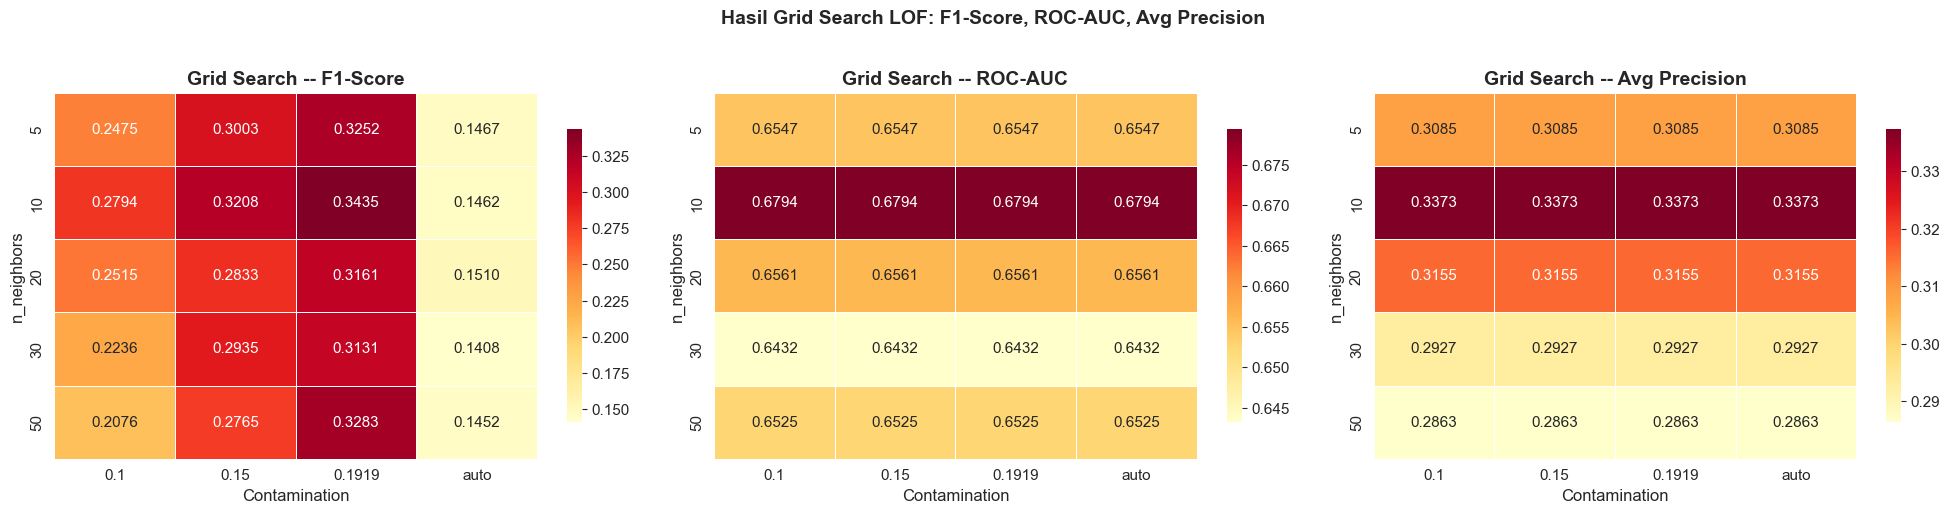

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, metric in enumerate(['F1-Score', 'ROC-AUC', 'Avg Precision']):
    pivot = df_results.pivot_table(
        index='n_neighbors', columns='contamination', values=metric
    )
    ax = axes[idx]
    sns.heatmap(
        pivot, annot=True, fmt='.4f', cmap='YlOrRd',
        ax=ax, linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(f'Grid Search -- {metric}', fontweight='bold')
    ax.set_xlabel('Contamination')
    ax.set_ylabel('n_neighbors')

plt.suptitle('Hasil Grid Search LOF: F1-Score, ROC-AUC, Avg Precision',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

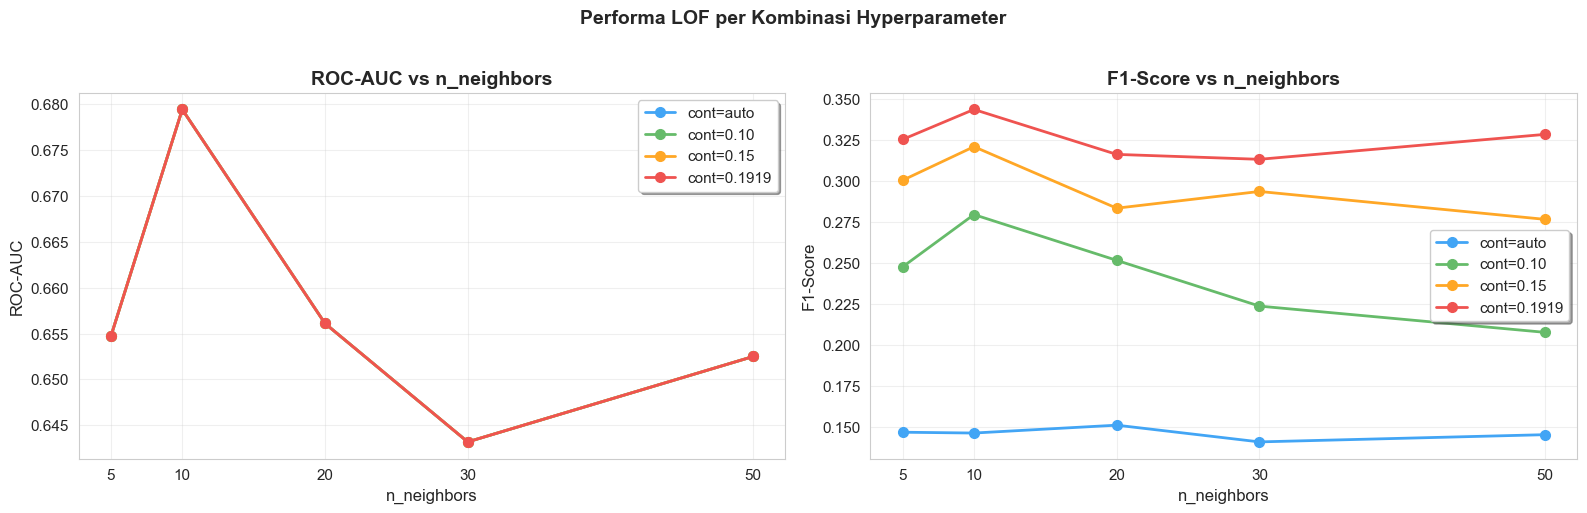

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_cont  = ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350']
cont_labels  = ['auto', '0.10', '0.15', '0.1919']

for ax, metric in zip(axes, ['ROC-AUC', 'F1-Score']):
    for cont, color, label in zip(CONTAMINATION_LIST, colors_cont, cont_labels):
        subset = df_results[df_results['contamination'] == cont]
        ax.plot(subset['n_neighbors'], subset[metric],
                'o-', color=color, linewidth=2, markersize=7, label=f'cont={label}')
    ax.set_xlabel('n_neighbors')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs n_neighbors', fontweight='bold')
    ax.legend(frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(N_NEIGHBORS_LIST)

plt.suptitle('Performa LOF per Kombinasi Hyperparameter', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Model Terbaik: n_neighbors=10, contamination=0.1919

Berdasarkan grid search, konfigurasi **`n_neighbors=10`** memberikan ROC-AUC tertinggi (0.6794) dan Avg Precision tertinggi (0.3373) secara konsisten.
Contamination **0.1919** (rasio krisis aktual) dipilih karena memberikan keseimbangan Precision-Recall terbaik (Precision = Recall = F1).

In [60]:
BEST_N_NEIGHBORS   = 10
BEST_CONTAMINATION = 0.1919

lof_best = LocalOutlierFactor(
    n_neighbors=BEST_N_NEIGHBORS,
    contamination=BEST_CONTAMINATION,
    metric='minkowski',
    algorithm='auto',
    novelty=False
)

pred_best  = lof_best.fit_predict(X)
y_pred     = (pred_best == -1).astype(int)
lof_scores = -lof_best.negative_outlier_factor_

print('='*60)
print('  MODEL LOF TERBAIK')
print('='*60)
print(f'  n_neighbors  : {BEST_N_NEIGHBORS}')
print(f'  contamination: {BEST_CONTAMINATION}')
print(f'  metric       : Euclidean (Minkowski p=2)')
print()
print(f'  Anomali terdeteksi: {y_pred.sum()} ({y_pred.mean()*100:.1f}%)')
print(f'  Normal            : {(y_pred==0).sum()} ({(y_pred==0).mean()*100:.1f}%)')
print('='*60)

  MODEL LOF TERBAIK
  n_neighbors  : 10
  contamination: 0.1919
  metric       : Euclidean (Minkowski p=2)

  Anomali terdeteksi: 329 (19.2%)
  Normal            : 1385 (80.8%)


## 8. Evaluasi Model terhadap Ground Truth

In [61]:
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)
roc_auc   = roc_auc_score(y_true, lof_scores)
avg_prec  = average_precision_score(y_true, lof_scores)

print('='*60)
print('  EVALUASI LOF vs GROUND TRUTH KRISIS')
print('='*60)
print(f'  Precision     : {precision:.4f}  ({precision*100:.1f}%)')
print(f'  Recall        : {recall:.4f}  ({recall*100:.1f}%)')
print(f'  F1-Score      : {f1:.4f}')
print(f'  ROC-AUC       : {roc_auc:.4f}')
print(f'  Avg Precision : {avg_prec:.4f}')
print('='*60)
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Krisis']))

  EVALUASI LOF vs GROUND TRUTH KRISIS
  Precision     : 0.3435  (34.3%)
  Recall        : 0.3435  (34.3%)
  F1-Score      : 0.3435
  ROC-AUC       : 0.6794
  Avg Precision : 0.3373

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.84      0.84      1385
      Krisis       0.34      0.34      0.34       329

    accuracy                           0.75      1714
   macro avg       0.59      0.59      0.59      1714
weighted avg       0.75      0.75      0.75      1714



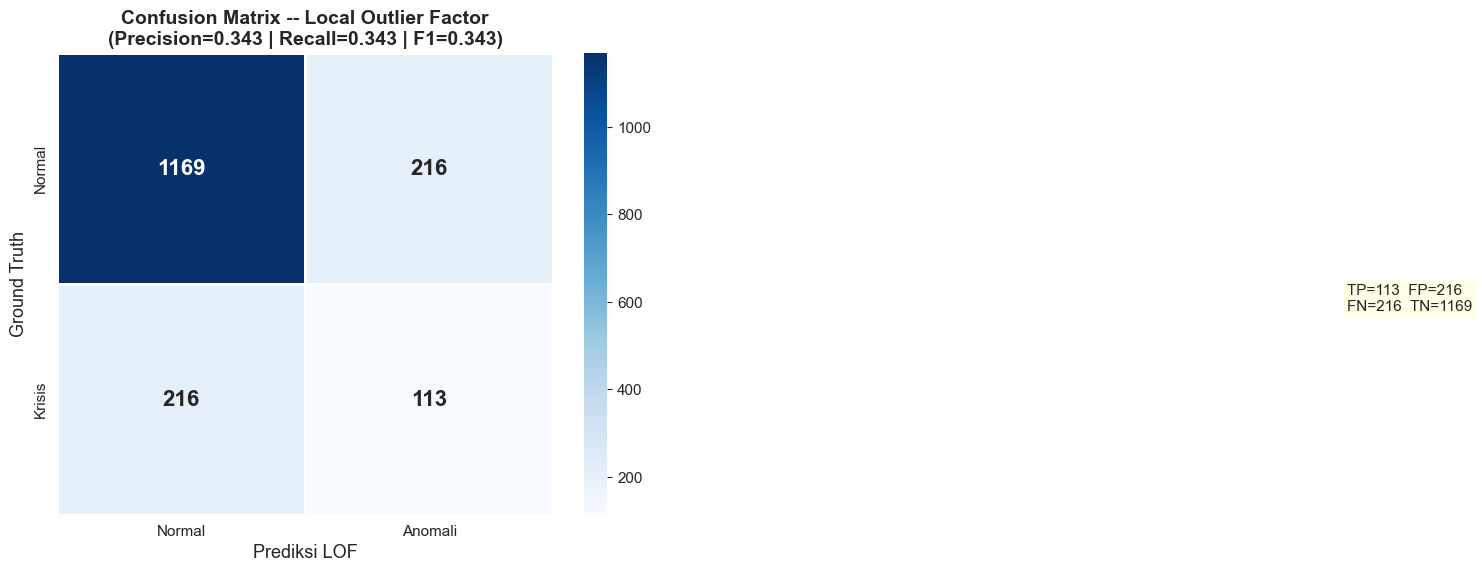

In [62]:
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal', 'Anomali'],
    yticklabels=['Normal', 'Krisis'],
    linewidths=2, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'},
    ax=ax
)
ax.set_xlabel('Prediksi LOF', fontsize=13)
ax.set_ylabel('Ground Truth', fontsize=13)
ax.set_title(
    f'Confusion Matrix -- Local Outlier Factor\n'
    f'(Precision={precision:.3f} | Recall={recall:.3f} | F1={f1:.3f})',
    fontsize=14, fontweight='bold'
)
textstr = f'TP={tp}  FP={fp}\nFN={fn}  TN={tn}'
props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
ax.text(2.6, 0.5, textstr, fontsize=11, verticalalignment='top', bbox=props, transform=ax.transAxes)
plt.tight_layout()
plt.show()

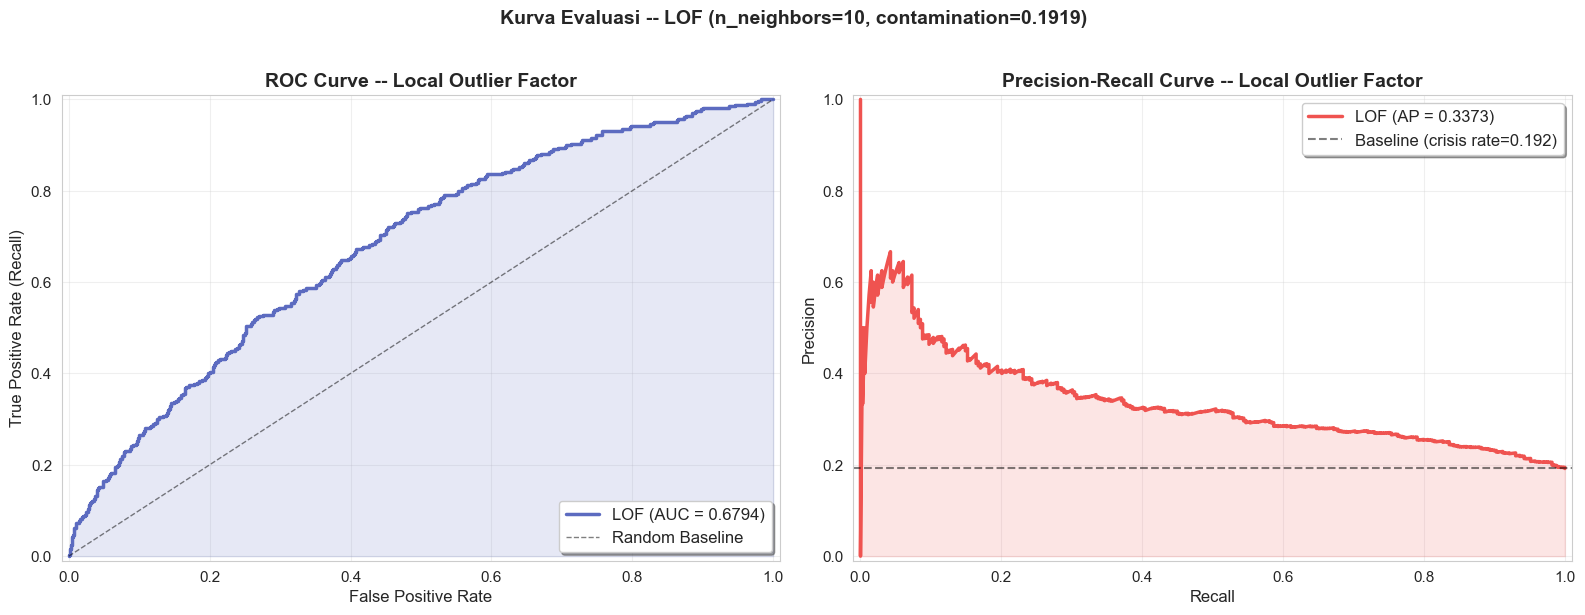

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, lof_scores)
ax = axes[0]
ax.plot(fpr, tpr, color='#5C6BC0', linewidth=2.5, label=f'LOF (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Baseline')
ax.fill_between(fpr, tpr, alpha=0.15, color='#5C6BC0')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve -- Local Outlier Factor', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])

# Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_true, lof_scores)
ax = axes[1]
ax.plot(rec_curve, prec_curve, color='#EF5350', linewidth=2.5, label=f'LOF (AP = {avg_prec:.4f})')
ax.axhline(y=y_true.mean(), color='k', linestyle='--', alpha=0.5,
           label=f'Baseline (crisis rate={y_true.mean():.3f})')
ax.fill_between(rec_curve, prec_curve, alpha=0.15, color='#EF5350')
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve -- Local Outlier Factor', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])

plt.suptitle('Kurva Evaluasi -- LOF (n_neighbors=10, contamination=0.1919)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Perbandingan antar Contamination (n_neighbors=10)

In [64]:
df_n10 = df_results[df_results['n_neighbors'] == BEST_N_NEIGHBORS].copy()
df_n10['contamination'] = df_n10['contamination'].astype(str)
df_n10 = df_n10[['contamination','TP','FP','TN','FN','Precision','Recall','F1-Score','ROC-AUC','Avg Precision']]
df_n10 = df_n10.reset_index(drop=True)

print('Perbandingan Contamination (n_neighbors=10):')
print('='*90)
print(df_n10.to_string(index=False))
print('='*90)
df_n10

Perbandingan Contamination (n_neighbors=10):
contamination  TP  FP   TN  FN  Precision  Recall  F1-Score  ROC-AUC  Avg Precision
         auto  28  26 1359 301     0.5185  0.0851    0.1462   0.6794         0.3373
          0.1  70 102 1283 259     0.4070  0.2128    0.2794   0.6794         0.3373
         0.15  94 163 1222 235     0.3658  0.2857    0.3208   0.6794         0.3373
       0.1919 113 216 1169 216     0.3435  0.3435    0.3435   0.6794         0.3373


,contamination,TP,FP,TN,FN,Precision,Recall,F1-Score,ROC-AUC,Avg Precision
0,auto,28,26,1359,301,0.5185,0.0851,0.1462,0.6794,0.3373
1,0.1,70,102,1283,259,0.4070,0.2128,0.2794,0.6794,0.3373
2,0.15,94,163,1222,235,0.3658,0.2857,0.3208,0.6794,0.3373
3,0.1919,113,216,1169,216,0.3435,0.3435,0.3435,0.6794,0.3373


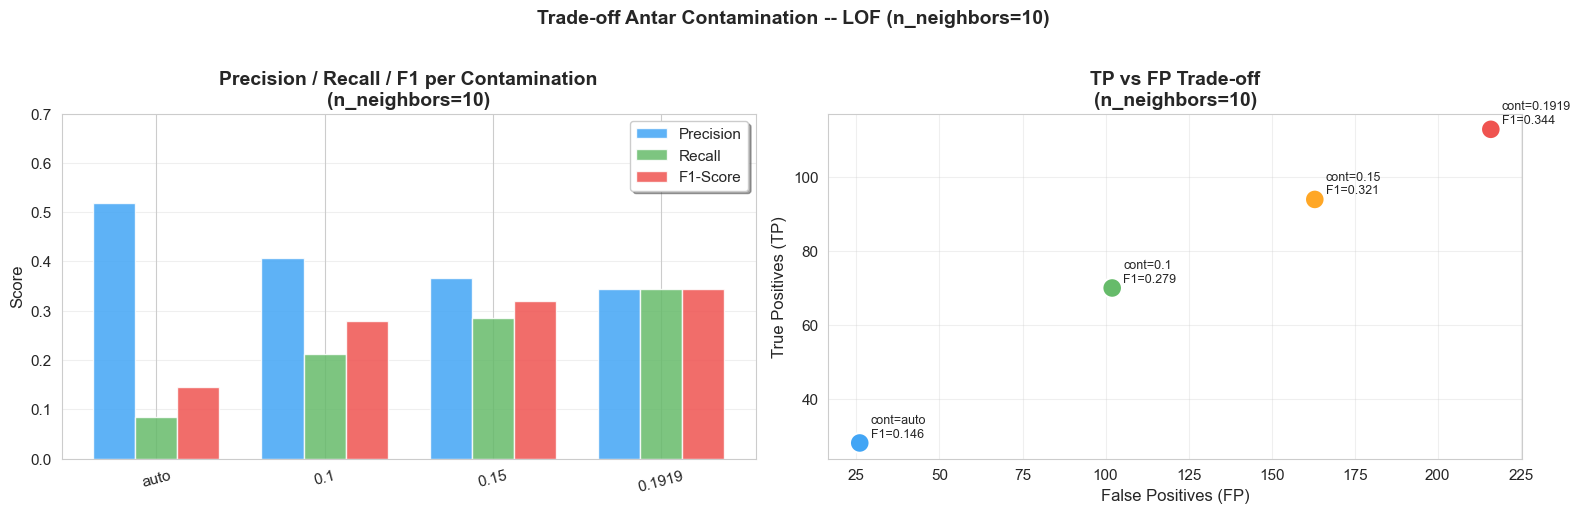

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = range(len(df_n10))
colors_bar = ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350']

# Precision-Recall-F1
ax = axes[0]
width = 0.25
ax.bar([i - width for i in x], df_n10['Precision'], width, label='Precision', color='#42A5F5', alpha=0.85, edgecolor='white')
ax.bar([i for i in x],          df_n10['Recall'],    width, label='Recall',    color='#66BB6A', alpha=0.85, edgecolor='white')
ax.bar([i + width for i in x],  df_n10['F1-Score'],  width, label='F1-Score',  color='#EF5350', alpha=0.85, edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(df_n10['contamination'], rotation=15)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 per Contamination\n(n_neighbors=10)', fontweight='bold')
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 0.7)

# TP vs FP scatter
ax = axes[1]
ax.scatter(df_n10['FP'], df_n10['TP'], s=200,
           c=colors_bar[:len(df_n10)], zorder=5, edgecolors='white', linewidths=1.5)
for _, row in df_n10.iterrows():
    ax.annotate(f'cont={row["contamination"]}\nF1={row["F1-Score"]:.3f}',
                (row['FP'], row['TP']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)
ax.set_xlabel('False Positives (FP)'); ax.set_ylabel('True Positives (TP)')
ax.set_title('TP vs FP Trade-off\n(n_neighbors=10)', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Trade-off Antar Contamination -- LOF (n_neighbors=10)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Distribusi LOF Score

In [66]:
df['lof_score']         = lof_scores
df['predicted_anomaly'] = y_pred

print('Statistik LOF Score:')
print(f'   Mean  : {lof_scores.mean():.4f}')
print(f'   Median: {np.median(lof_scores):.4f}')
print(f'   Std   : {lof_scores.std():.4f}')
print(f'   Min   : {lof_scores.min():.4f}')
print(f'   Max   : {lof_scores.max():.4f}')

Statistik LOF Score:
   Mean  : 1.1033
   Median: 1.0506
   Std   : 0.1483
   Min   : 0.9289
   Max   : 1.9684


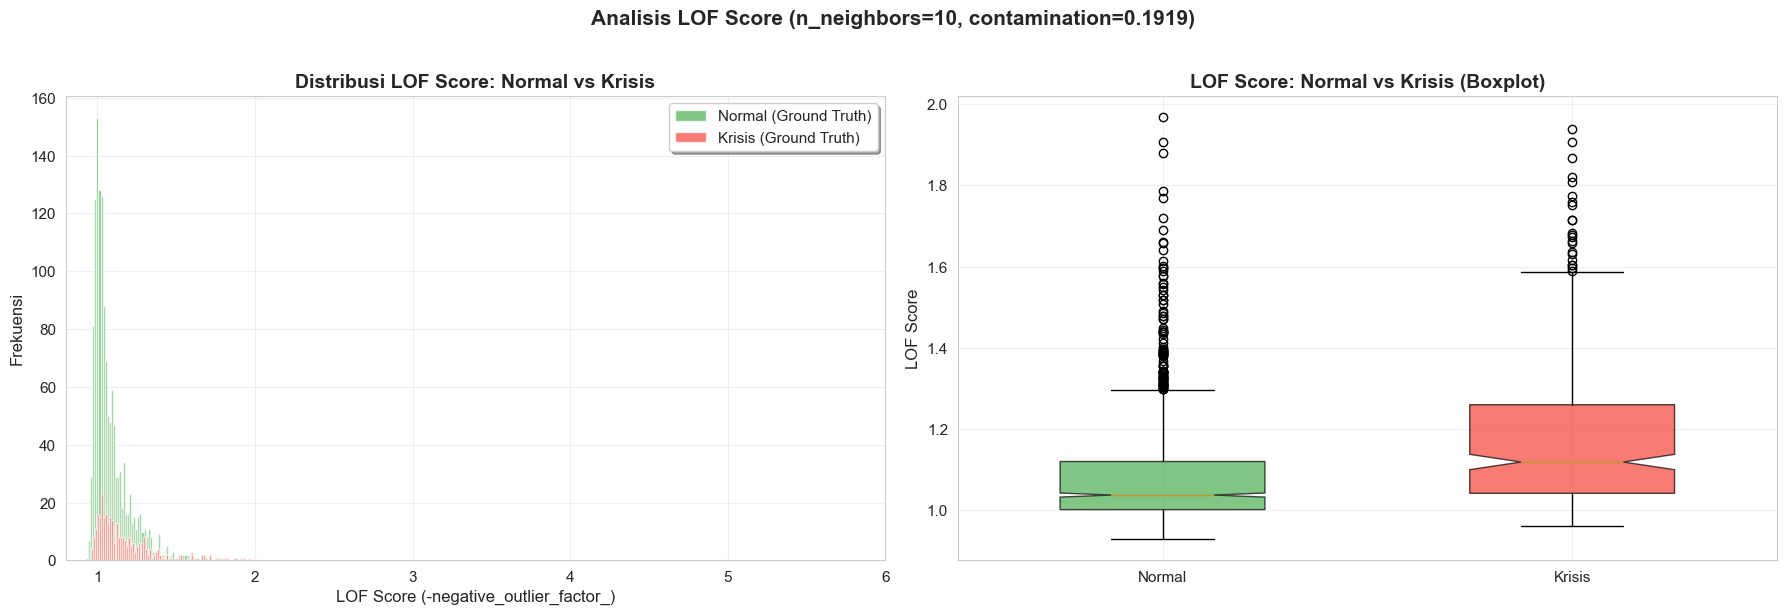

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
ax.hist(lof_scores[y_true == 0], bins=80, alpha=0.7,
        color='#4CAF50', label='Normal (Ground Truth)', edgecolor='white')
ax.hist(lof_scores[y_true == 1], bins=80, alpha=0.7,
        color='#F44336', label='Krisis (Ground Truth)', edgecolor='white')
ax.set_xlabel('LOF Score (-negative_outlier_factor_)')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi LOF Score: Normal vs Krisis', fontweight='bold')
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.set_xlim(0.8, 6); ax.grid(True, alpha=0.3)

ax = axes[1]
data_box = [lof_scores[y_true == 0], lof_scores[y_true == 1]]
bp = ax.boxplot(data_box, labels=['Normal', 'Krisis'],
                patch_artist=True, notch=True, widths=0.5)
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#F44336')
for box in bp['boxes']: box.set_alpha(0.7)
ax.set_ylabel('LOF Score')
ax.set_title('LOF Score: Normal vs Krisis (Boxplot)', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Analisis LOF Score (n_neighbors=10, contamination=0.1919)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Analisis Deteksi per Krisis Historis

In [68]:
CRISIS_EVENTS = {
    'Krisis Asia 1997-98': {
        'years': [1997, 1998],
        'countries': ['IDN', 'THA', 'MYS', 'KOR', 'PHL', 'HKG', 'SGP', 'TWN', 'VNM']
    },
    'Krisis Rusia 1998': {
        'years': [1998],
        'countries': ['RUS']
    },
    'Krisis Argentina 2001-02': {
        'years': [2001, 2002],
        'countries': ['ARG']
    },
    'Global Financial Crisis 2008-09': {
        'years': [2008, 2009],
        'countries': df['economy'].unique().tolist()
    },
    'Krisis Utang Eropa 2010-12': {
        'years': [2010, 2011, 2012],
        'countries': ['GRC', 'PRT', 'IRL', 'ESP', 'ITA']
    },
    'Pandemi COVID-19 2020': {
        'years': [2020],
        'countries': df['economy'].unique().tolist()
    }
}

print('='*75)
print('  ANALISIS DETEKSI PER KRISIS HISTORIS -- LOF')
print('='*75)

crisis_results = []
for crisis_name, info in CRISIS_EVENTS.items():
    mask = (df['year'].isin(info['years'])) & (df['economy'].isin(info['countries']))
    subset = df[mask]
    if len(subset) == 0: continue

    detected      = subset['predicted_anomaly'].sum()
    total         = len(subset)
    detection_rate = detected / total * 100
    avg_score     = subset['lof_score'].mean()

    crisis_results.append({
        'Krisis': crisis_name,
        'Total Observasi': total,
        'Terdeteksi': detected,
        'Detection Rate (%)': round(detection_rate, 1),
        'Avg LOF Score': round(avg_score, 4)
    })

    print(f'\n  {crisis_name}')
    print(f'    Observasi  : {total}')
    print(f'    Terdeteksi : {int(detected)}/{total} ({detection_rate:.1f}%)')
    print(f'    Avg LOF    : {avg_score:.4f}')
    if detected > 0:
        det_c = subset[subset['predicted_anomaly']==1]['economy'].unique()
        print(f'    Negara     : {", ".join(sorted(det_c))}')

print('\n' + '='*75)
df_crisis_results = pd.DataFrame(crisis_results)
df_crisis_results

  ANALISIS DETEKSI PER KRISIS HISTORIS -- LOF

  Krisis Asia 1997-98
    Observasi  : 14
    Terdeteksi : 7/14 (50.0%)
    Avg LOF    : 1.3008
    Negara     : IDN, KOR, MYS, PHL, SGP, THA

  Krisis Rusia 1998
    Observasi  : 1
    Terdeteksi : 0/1 (0.0%)
    Avg LOF    : 1.0934

  Krisis Argentina 2001-02
    Observasi  : 2
    Terdeteksi : 1/2 (50.0%)
    Avg LOF    : 1.3473
    Negara     : ARG

  Global Financial Crisis 2008-09
    Observasi  : 98
    Terdeteksi : 22/98 (22.4%)
    Avg LOF    : 1.1453
    Negara     : ARE, BEL, CHE, CHL, CHN, ESP, GBR, GRC, HUN, IRL, JPN, MYS, NLD, PHL, PRT, ROU, SAU, THA

  Krisis Utang Eropa 2010-12
    Observasi  : 15
    Terdeteksi : 9/15 (60.0%)
    Avg LOF    : 1.2484
    Negara     : ESP, GRC, IRL, PRT

  Pandemi COVID-19 2020
    Observasi  : 49
    Terdeteksi : 22/49 (44.9%)
    Avg LOF    : 1.2083
    Negara     : ARE, AUS, BEL, CHE, CHN, CZE, DEU, GRC, HUN, IDN, IND, JPN, KOR, LKA, NLD, NOR, POL, RUS, THA, TUR, USA, ZAF



,Krisis,Total Observasi,Terdeteksi,Detection Rate (%),Avg LOF Score
0,Krisis Asia 1997-98,14,7,50.0,1.3008
1,Krisis Rusia 1998,1,0,0.0,1.0934
2,Krisis Argentina 2001-02,2,1,50.0,1.3473
3,Global Financial Crisis 2008-09,98,22,22.4,1.1453
4,Krisis Utang Eropa 2010-12,15,9,60.0,1.2484
5,Pandemi COVID-19 2020,49,22,44.9,1.2083


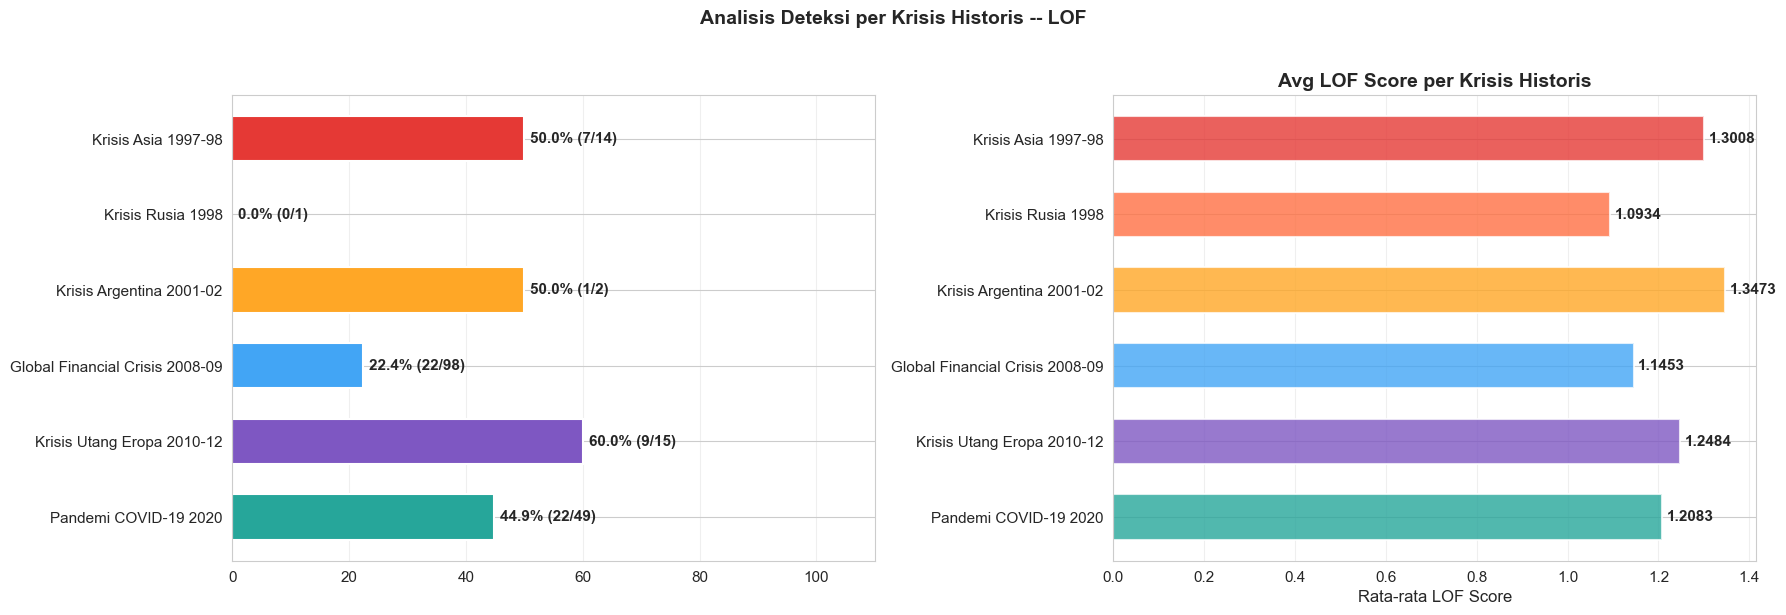

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors_crisis = ['#E53935', '#FF7043', '#FFA726', '#42A5F5', '#7E57C2', '#26A69A']

ax = axes[0]
bars = ax.barh(
    df_crisis_results['Krisis'],
    df_crisis_results['Detection Rate (%)'],
    color=colors_crisis[:len(df_crisis_results)],
    edgecolor='white', linewidth=1.5, height=0.6
)
for bar, (_, row) in zip(bars, df_crisis_results.iterrows()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{row["Detection Rate (%)"]:.1f}% ({int(row["Terdeteksi"])}/{row["Total Observasi"]})',
            va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 110); ax.grid(axis='x', alpha=0.3); ax.invert_yaxis()

ax = axes[1]
bars2 = ax.barh(
    df_crisis_results['Krisis'],
    df_crisis_results['Avg LOF Score'],
    color=colors_crisis[:len(df_crisis_results)],
    edgecolor='white', linewidth=1.5, height=0.6, alpha=0.8
)
for bar, (_, row) in zip(bars2, df_crisis_results.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{row["Avg LOF Score"]:.4f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Rata-rata LOF Score')
ax.set_title('Avg LOF Score per Krisis Historis', fontweight='bold')
ax.grid(axis='x', alpha=0.3); ax.invert_yaxis()

plt.suptitle('Analisis Deteksi per Krisis Historis -- LOF', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Reduksi Dimensi & Visualisasi

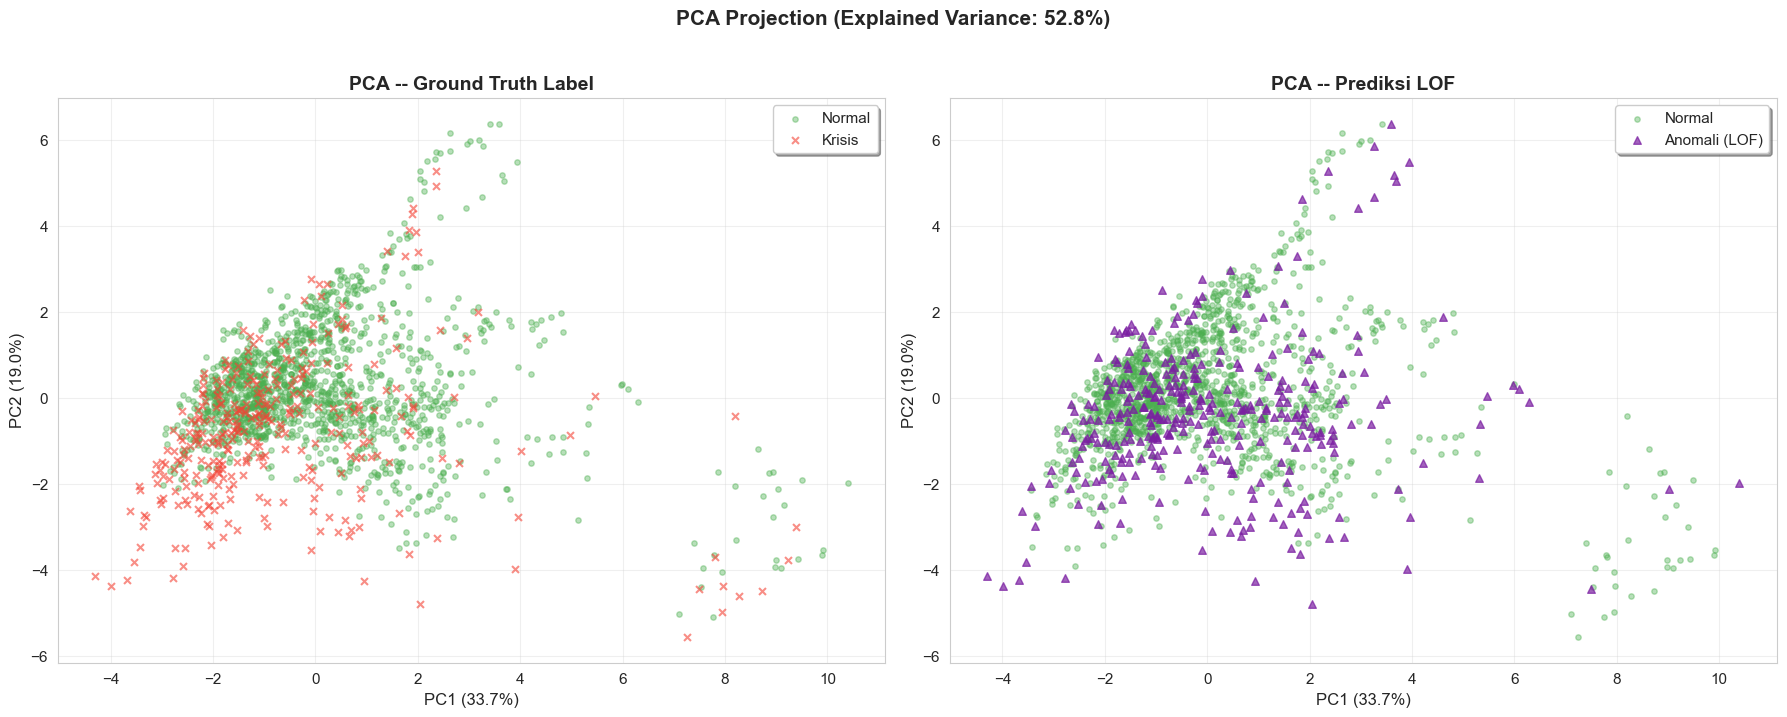

In [70]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
ax.scatter(X_pca[y_true==0, 0], X_pca[y_true==0, 1], c='#4CAF50', alpha=0.4, s=15, label='Normal')
ax.scatter(X_pca[y_true==1, 0], X_pca[y_true==1, 1], c='#F44336', alpha=0.6, s=25, marker='x', label='Krisis')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA -- Ground Truth Label', fontweight='bold')
ax.legend(frameon=True, fancybox=True, shadow=True); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(X_pca[y_pred==0, 0], X_pca[y_pred==0, 1], c='#4CAF50', alpha=0.4, s=15, label='Normal')
ax.scatter(X_pca[y_pred==1, 0], X_pca[y_pred==1, 1], c='#7B1FA2', alpha=0.7, s=30, marker='^', label='Anomali (LOF)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA -- Prediksi LOF', fontweight='bold')
ax.legend(frameon=True, fancybox=True, shadow=True); ax.grid(True, alpha=0.3)

plt.suptitle(f'PCA Projection (Explained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

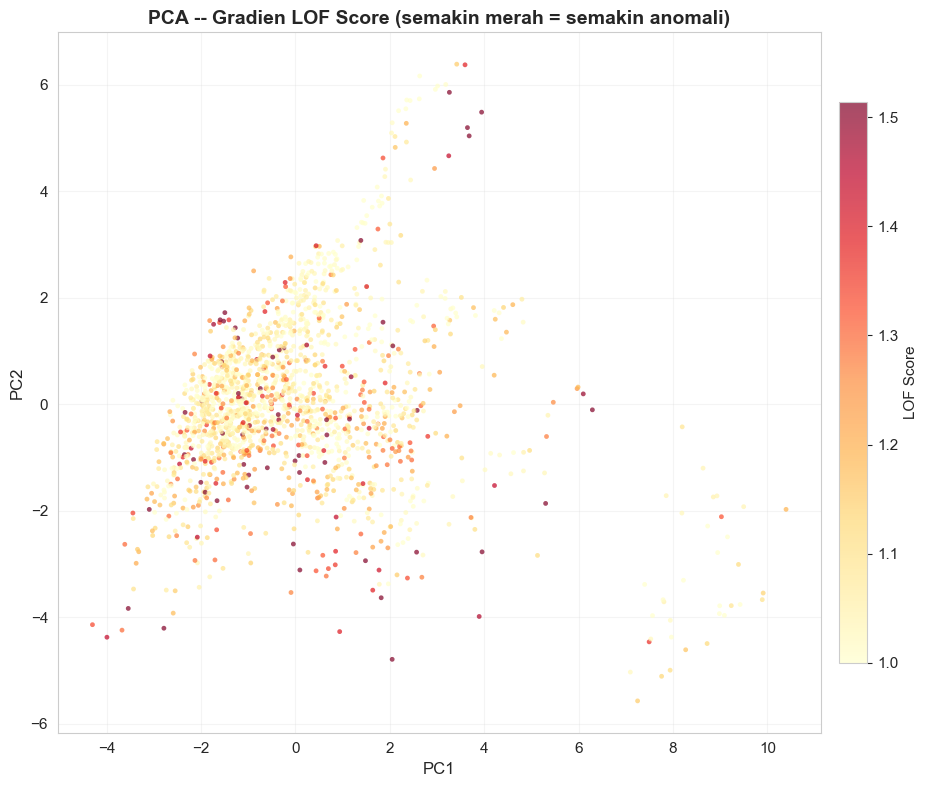

In [71]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=lof_scores, cmap='YlOrRd', s=12, alpha=0.7, edgecolors='none',
    vmin=1, vmax=np.percentile(lof_scores, 97)
)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('LOF Score', fontsize=11)
ax.set_xlabel('PC1', fontsize=12); ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA -- Gradien LOF Score (semakin merah = semakin anomali)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Menjalankan t-SNE...
t-SNE selesai!


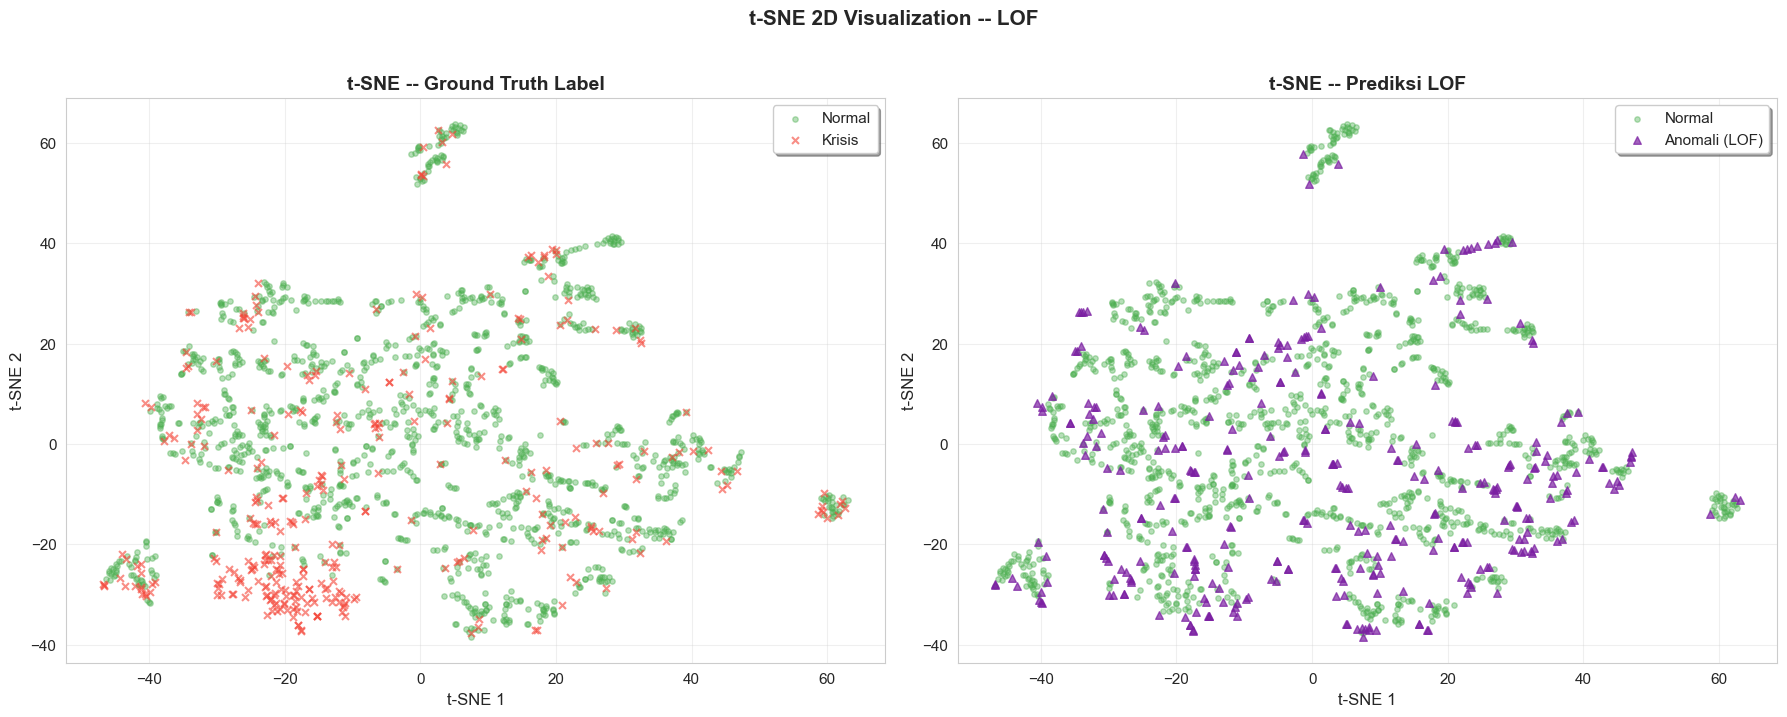

In [72]:
print('Menjalankan t-SNE...')
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED,
            max_iter=1000, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X)
print('t-SNE selesai!')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
ax.scatter(X_tsne[y_true==0, 0], X_tsne[y_true==0, 1], c='#4CAF50', alpha=0.4, s=15, label='Normal')
ax.scatter(X_tsne[y_true==1, 0], X_tsne[y_true==1, 1], c='#F44336', alpha=0.6, s=25, marker='x', label='Krisis')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE -- Ground Truth Label', fontweight='bold')
ax.legend(frameon=True, fancybox=True, shadow=True); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter(X_tsne[y_pred==0, 0], X_tsne[y_pred==0, 1], c='#4CAF50', alpha=0.4, s=15, label='Normal')
ax.scatter(X_tsne[y_pred==1, 0], X_tsne[y_pred==1, 1], c='#7B1FA2', alpha=0.7, s=30, marker='^', label='Anomali (LOF)')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE -- Prediksi LOF', fontweight='bold')
ax.legend(frameon=True, fancybox=True, shadow=True); ax.grid(True, alpha=0.3)

plt.suptitle('t-SNE 2D Visualization -- LOF', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

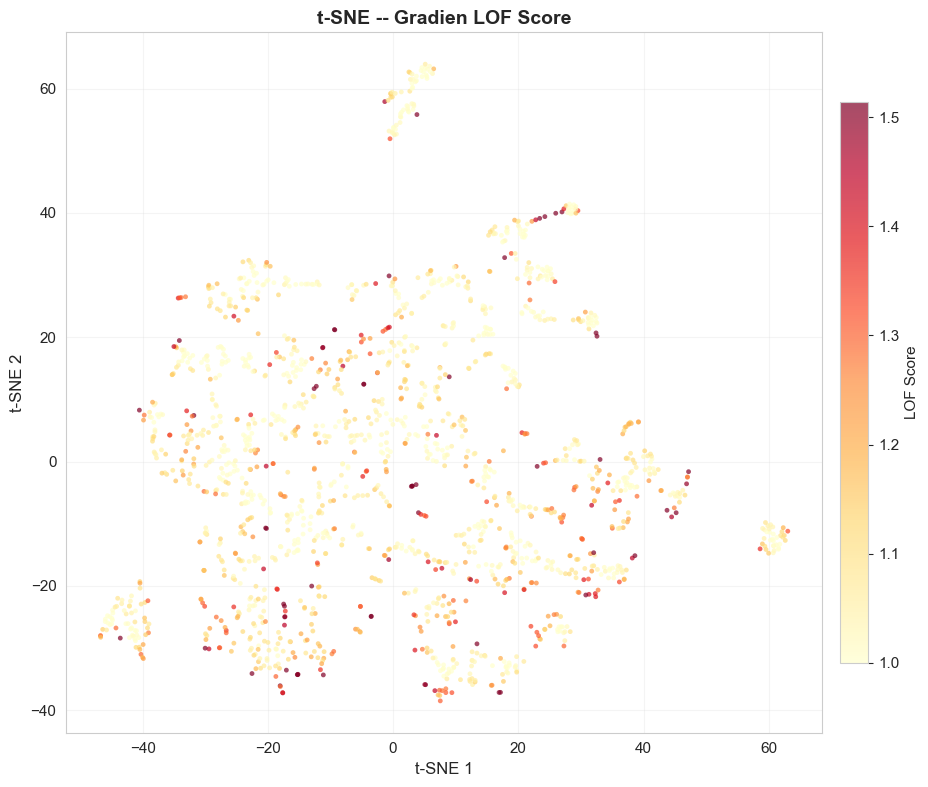

In [73]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=lof_scores, cmap='YlOrRd', s=12, alpha=0.7, edgecolors='none',
    vmin=1, vmax=np.percentile(lof_scores, 97)
)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('LOF Score', fontsize=11)
ax.set_xlabel('t-SNE 1', fontsize=12); ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE -- Gradien LOF Score', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 13. Analisis Top Anomali

In [74]:
top_anomalies = df.nlargest(30, 'lof_score')[
    ['economy', 'year', 'lof_score', 'predicted_anomaly', 'crisis_label']
].copy()

top_anomalies['Status'] = top_anomalies.apply(
    lambda row: 'True Positive'  if row['predicted_anomaly']==1 and row['crisis_label']==1
    else ('False Positive' if row['predicted_anomaly']==1 and row['crisis_label']==0
    else 'Missed'),
    axis=1
)

print('Top 30 Observasi dengan LOF Score Tertinggi:')
print('='*70)
top_anomalies.reset_index(drop=True)

Top 30 Observasi dengan LOF Score Tertinggi:


,economy,year,lof_score,predicted_anomaly,crisis_label,Status
0,KEN,1994,1.968425,1,0,False Positive
1,IDN,1998,1.938805,1,1,True Positive
2,CHN,2008,1.906141,1,0,False Positive
3,BRA,1993,1.905917,1,1,True Positive
4,PER,1991,1.880679,1,0,False Positive
5,BRA,1994,1.867566,1,1,True Positive
6,JPN,2020,1.820463,1,1,True Positive
7,JPN,2009,1.809322,1,1,True Positive
8,CHN,2009,1.787317,1,0,False Positive
9,KEN,1993,1.773353,1,1,True Positive


In [75]:
country_anomalies = df[df['predicted_anomaly']==1].groupby('economy').agg(
    anomaly_count=('predicted_anomaly', 'sum'),
    avg_lof=('lof_score', 'mean'),
    years_detected=('year', lambda x: ', '.join(map(str, sorted(x))))
).sort_values('anomaly_count', ascending=False)

print('Negara dengan Anomali Terbanyak (LOF):')
print('='*70)
country_anomalies.head(15)

Negara dengan Anomali Terbanyak (LOF):


,anomaly_count,avg_lof,years_detected
economy,,,
IRL,27,1.410888,"1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997..."
SAU,23,1.352274,"1990, 1991, 1992, 1993, 1995, 1996, 1997, 2000..."
NGA,21,1.288366,"1990, 1992, 1995, 1996, 1998, 1999, 2000, 2001..."
GRC,16,1.325865,"2005, 2006, 2007, 2009, 2010, 2011, 2012, 2013..."
ROU,15,1.367605,"1990, 1991, 1992, 1993, 1997, 1998, 1999, 2000..."
HUN,15,1.292675,"1993, 1994, 1995, 1996, 2005, 2007, 2009, 2011..."
CHE,14,1.271722,"1990, 1991, 2006, 2009, 2014, 2015, 2016, 2017..."
RUS,10,1.370835,"1990, 1991, 1992, 1993, 1994, 1999, 2000, 2015..."
NLD,10,1.267299,"1999, 2002, 2003, 2009, 2010, 2014, 2018, 2020..."


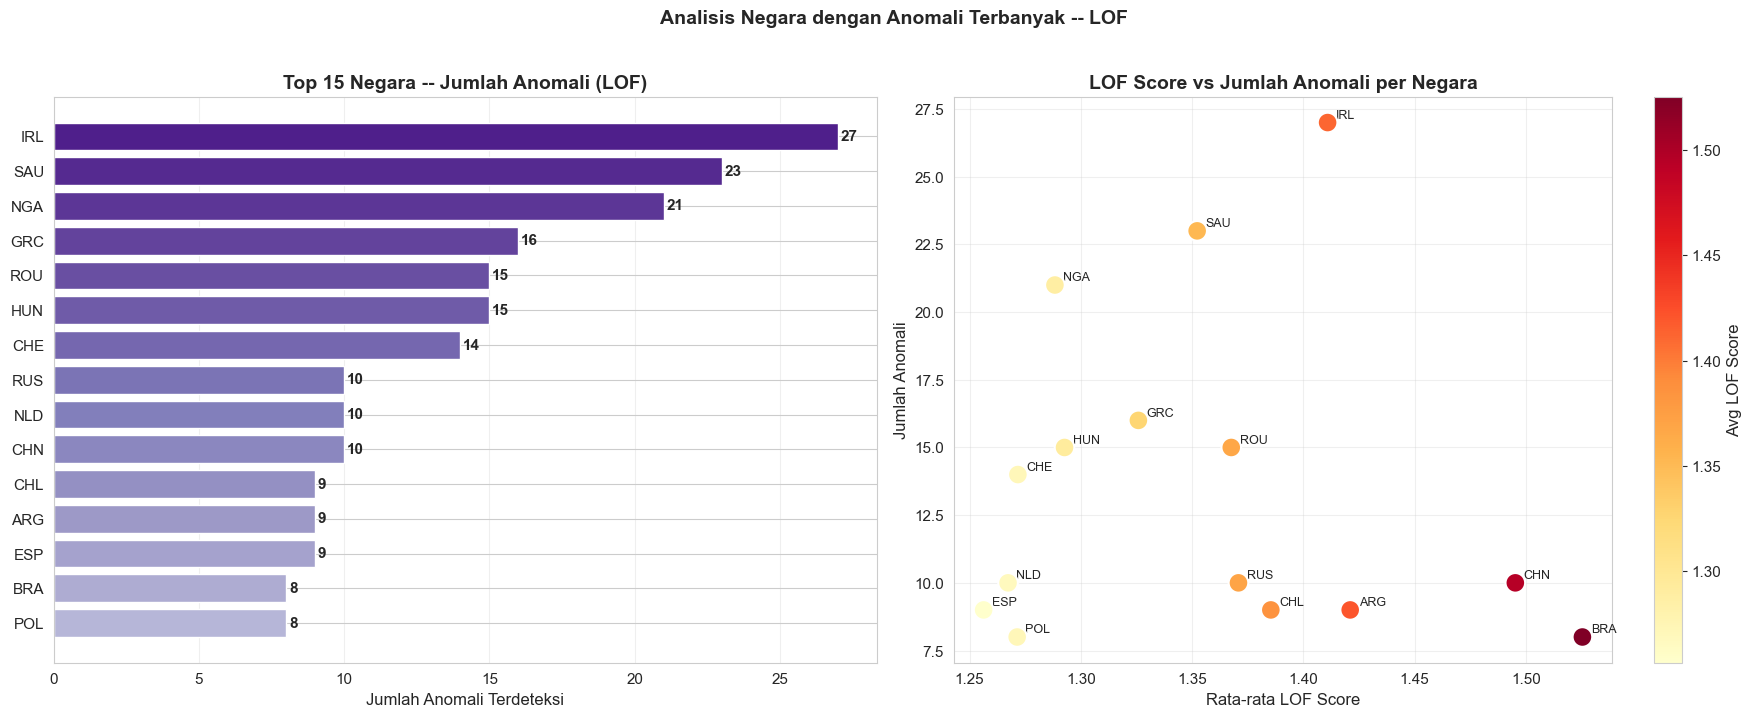

In [76]:
top15 = country_anomalies.head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
colors_grad = plt.cm.Purples(np.linspace(0.4, 0.9, 15))
bars = ax.barh(
    top15.index[::-1], top15['anomaly_count'][::-1],
    color=colors_grad, edgecolor='white', linewidth=1
)
for bar, count in zip(bars, top15['anomaly_count'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(count)), va='center', fontweight='bold', fontsize=11)
ax.set_xlabel('Jumlah Anomali Terdeteksi', fontsize=12)
ax.set_title('Top 15 Negara -- Jumlah Anomali (LOF)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
scatter = ax.scatter(
    top15['avg_lof'], top15['anomaly_count'],
    s=200, c=top15['avg_lof'], cmap='YlOrRd',
    zorder=5, edgecolors='white', linewidths=1.5
)
for country, row in top15.iterrows():
    ax.annotate(country, (row['avg_lof'], row['anomaly_count']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
plt.colorbar(scatter, ax=ax, label='Avg LOF Score')
ax.set_xlabel('Rata-rata LOF Score', fontsize=12)
ax.set_ylabel('Jumlah Anomali', fontsize=12)
ax.set_title('LOF Score vs Jumlah Anomali per Negara', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Analisis Negara dengan Anomali Terbanyak -- LOF',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Timeline Anomali -- Perspektif Temporal

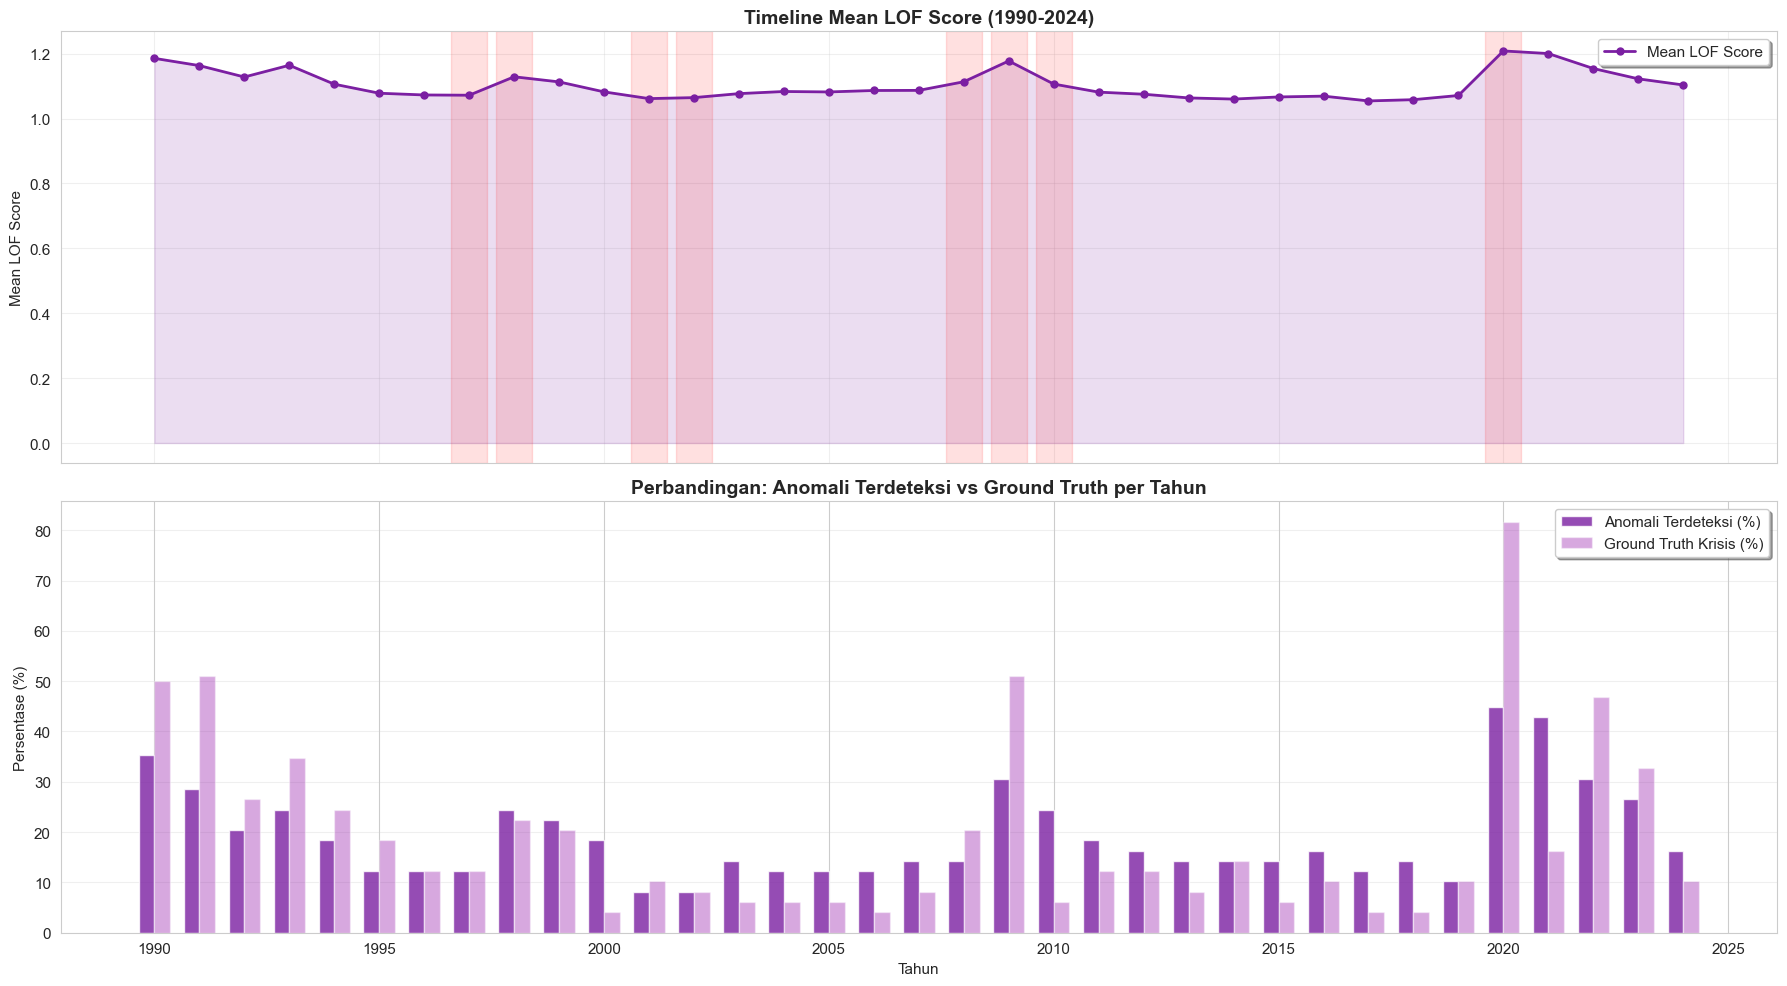

In [77]:
yearly_stats = df.groupby('year').agg(
    mean_lof=('lof_score', 'mean'),
    median_lof=('lof_score', 'median'),
    anomaly_count=('predicted_anomaly', 'sum'),
    total_count=('predicted_anomaly', 'count'),
    crisis_count=('crisis_label', 'sum')
).reset_index()

yearly_stats['anomaly_pct'] = yearly_stats['anomaly_count'] / yearly_stats['total_count'] * 100
yearly_stats['crisis_pct']  = yearly_stats['crisis_count']  / yearly_stats['total_count'] * 100

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

ax = axes[0]
ax.plot(yearly_stats['year'], yearly_stats['mean_lof'],
        'o-', color='#7B1FA2', linewidth=2, markersize=5, label='Mean LOF Score')
ax.fill_between(yearly_stats['year'], yearly_stats['mean_lof'], alpha=0.15, color='#7B1FA2')
crisis_years_major = [1997, 1998, 2001, 2002, 2008, 2009, 2010, 2020]
for cy in crisis_years_major:
    if cy in yearly_stats['year'].values:
        ax.axvspan(cy-0.4, cy+0.4, alpha=0.12, color='red')
ax.set_ylabel('Mean LOF Score', fontsize=11)
ax.set_title('Timeline Mean LOF Score (1990-2024)', fontsize=14, fontweight='bold')
ax.legend(frameon=True, fancybox=True, shadow=True); ax.grid(True, alpha=0.3)

ax = axes[1]
width = 0.35
ax.bar(yearly_stats['year'] - width/2, yearly_stats['anomaly_pct'],
       width, color='#7B1FA2', alpha=0.8, label='Anomali Terdeteksi (%)', edgecolor='white')
ax.bar(yearly_stats['year'] + width/2, yearly_stats['crisis_pct'],
       width, color='#9C27B0', alpha=0.4, label='Ground Truth Krisis (%)', edgecolor='white')
ax.set_xlabel('Tahun', fontsize=11); ax.set_ylabel('Persentase (%)', fontsize=11)
ax.set_title('Perbandingan: Anomali Terdeteksi vs Ground Truth per Tahun',
             fontsize=14, fontweight='bold')
ax.legend(frameon=True, fancybox=True, shadow=True)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Ekspor Hasil

In [78]:
output_cols = ['economy', 'year', 'lof_score', 'predicted_anomaly', 'crisis_label']
df_output = df[output_cols].copy()
df_output.to_csv('hasil_lof.csv', index=False)

print('Hasil deteksi disimpan ke: hasil_lof.csv')
print(f'   Total baris  : {len(df_output)}')
print(f'   Anomali      : {df_output["predicted_anomaly"].sum()}')
print(f'   Kolom output : {list(df_output.columns)}')

df_n10.to_csv('ringkasan_model_lof.csv', index=False)
print('\nRingkasan model disimpan ke: ringkasan_model_lof.csv')

Hasil deteksi disimpan ke: hasil_lof.csv
   Total baris  : 1714
   Anomali      : 329
   Kolom output : ['economy', 'year', 'lof_score', 'predicted_anomaly', 'crisis_label']

Ringkasan model disimpan ke: ringkasan_model_lof.csv


## 16. Ringkasan Hasil

In [82]:
print('\n' + '='*70)
print('  RINGKASAN HASIL -- LOCAL OUTLIER FACTOR (LOF)')
print('  Early Warning System Krisis Ekonomi')
print('='*70)
print()
print('  DATASET')
print(f'    Observasi    : {len(df):,} (49 negara x 35 tahun)')
print(f'    Fitur        : {len(FEATURE_COLS)} indikator makroekonomi')
print(f'    Ground Truth : {y_true.sum()} krisis ({y_true.mean()*100:.1f}%)')
print()
print('  KONFIGURASI MODEL TERBAIK')
print(f'    Algoritma    : Local Outlier Factor (LOF)')
print(f'    n_neighbors  : {BEST_N_NEIGHBORS}')
print(f'    contamination: {BEST_CONTAMINATION}')
print(f'    metric       : Euclidean (Minkowski p=2)')
print()
print('  HASIL DETEKSI')
print(f'    Anomali      : {y_pred.sum()} terdeteksi ({y_pred.mean()*100:.1f}%)')
print(f'    Normal       : {(y_pred==0).sum()} tidak ditandai')
print()
print('  EVALUASI vs GROUND TRUTH')
print(f'    Precision    : {precision:.4f}')
print(f'    Recall       : {recall:.4f}')
print(f'    F1-Score     : {f1:.4f}')
print(f'    ROC-AUC      : {roc_auc:.4f}')
print(f'    Avg Precision: {avg_prec:.4f}')
print()
print('='*70)


  RINGKASAN HASIL -- LOCAL OUTLIER FACTOR (LOF)
  Early Warning System Krisis Ekonomi

  DATASET
    Observasi    : 1,714 (49 negara x 35 tahun)
    Fitur        : 14 indikator makroekonomi
    Ground Truth : 329 krisis (19.2%)

  KONFIGURASI MODEL TERBAIK
    Algoritma    : Local Outlier Factor (LOF)
    n_neighbors  : 10
    contamination: 0.1919
    metric       : Euclidean (Minkowski p=2)

  HASIL DETEKSI
    Anomali      : 329 terdeteksi (19.2%)
    Normal       : 1385 tidak ditandai

  EVALUASI vs GROUND TRUTH
    Precision    : 0.3435
    Recall       : 0.3435
    F1-Score     : 0.3435
    ROC-AUC      : 0.6794
    Avg Precision: 0.3373

